#Day 27 Evaluasi Model Regresi (RMSE, R², dan Cross-Validation)

- Membuat model itu sederhana;
- **mengukur sebaik apa model bekerja** adalah keterampilan yang membedakan praktisi pemula dengan profesional.
- Notebook ini fokus pada cara **mengevaluasi model regresi** secara benar dan adil — termasuk teknik andalan bernama **Cross-Validation**.

> 🎯 **Tujuan Pembelajaran**
> - Memahami arti & beda metrik **MAE**, **MSE**, **RMSE**, dan **R²**.
> - Menghitung metrik tersebut pada data uji.
> - Menggunakan **`cross_val_score`** (cv=5) untuk evaluasi yang lebih stabil.
> - Memvisualkan distribusi skor lintas-fold dan membahas **overfitting**.

## 📊 Tentang Dataset

Kita memakai **Boston Housing Dataset** — data harga rumah di kawasan Boston beserta
faktor-faktor lingkungannya. Target yang kita prediksi adalah **`MEDV`** (harga median
rumah, dalam ribuan dolar).

- **Sumber:** [Kaggle — fedesoriano/the-boston-houseprice-data](https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data)
- **Jumlah data:** 506 baris × 14 kolom

| Kolom | Arti singkat |
|-------|------|
| `CRIM` | Tingkat kriminalitas per kapita |
| `RM` | Rata-rata jumlah kamar per rumah |
| `LSTAT` | % penduduk berstatus ekonomi rendah |
| `PTRATIO` | Rasio murid-guru |
| `NOX` | Konsentrasi oksida nitrat (polusi) |
| `MEDV` | **(Target)** Harga median rumah (ribuan $) |

## Import Library

- **pandas / numpy** → olah data & angka.
- **matplotlib / seaborn** → grafik.
- **scikit-learn** → model `LinearRegression`, pembagian data (`train_test_split`),
  metrik (`mean_squared_error`, `mean_absolute_error`, `r2_score`), dan
  `cross_val_score` untuk validasi silang.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Import Dataset

In [22]:
!pip install kaggle
!kaggle datasets download -d fedesoriano/the-boston-houseprice-data
!unzip the-boston-houseprice-data.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data
License(s): copyright-authors
the-boston-houseprice-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  the-boston-houseprice-data.zip
replace boston.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: boston.csv              


## Eksplorasi Awal Dataset

In [23]:
df = pd.read_csv('boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [24]:
print("Bentuk Data:", df.shape)

print("Jumlah Missing Value:", df.isna().sum().sum())

df.info()

Bentuk Data: (506, 14)
Jumlah Missing Value: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [25]:
df.describe()[['CRIM','RM','LSTAT','PTRATIO','MEDV']].T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
LSTAT,506.0,12.653063,7.141062,1.73000,6.950000,11.36000,16.955000,37.9700
PTRATIO,506.0,18.455534,2.164946,12.60000,17.400000,19.05000,20.200000,22.0000
MEDV,506.0,22.532806,9.197104,5.00000,17.025000,21.20000,25.000000,50.0000


Interpretasi:
-  Setiap baris adalah satu kawasan. Semua kolom bertipe angka, jadi data ini siap dipakai untuk regresi tanpa encoding.
- Ada **506 baris × 14 kolom**, semuanya numerik dan tidak ada nilai kosong — kondisi ideal untuk fokus belajar evaluasi model.
- Harga rumah (`MEDV`) berkisar dari ~5 hingga 50 (ribu $), dengan rata-rata sekitar 22. Rentang yang lebar ini penting diingat saat menafsirkan RMSE nanti.

## Eksplorasi Data Analisis dan Visualisasi Data

### a) Heatmap Korelasi

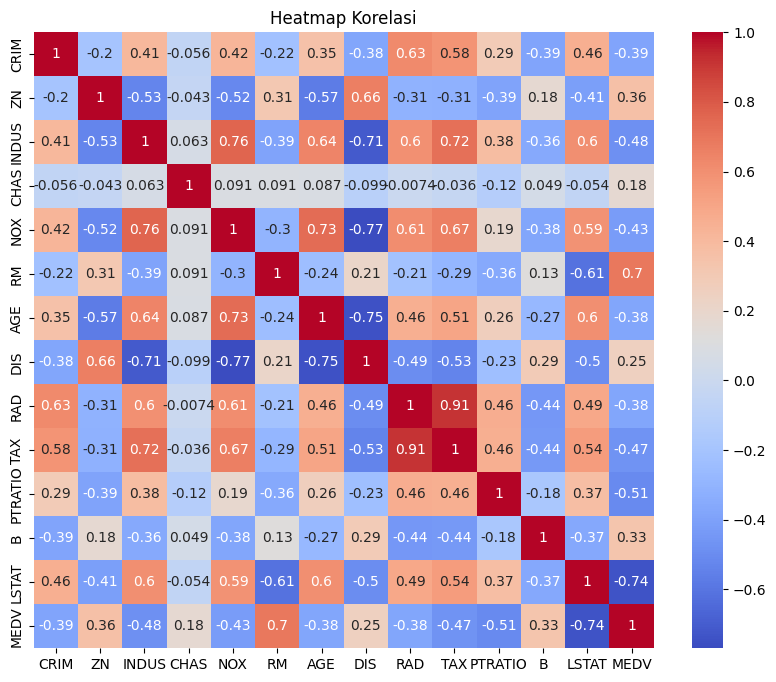

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')

plt.show()

Interpretasi:
- `RM` mempunyain korelasi positif kuat dengan MEDV
- `LSTAT`(status ekonomi rendah) mempunyai kolerasi negatif kuat dengan MEDV,
Beberapa fitur saling berkorelasi (mis. `RAD` & `TAX`, `NOX` & `INDUS`).
- Korelasi antar fitur (multikolinearitas) membuat koefisien linear biasa

### b) Hubungan RM vs MEDV ( ScatterPlot )

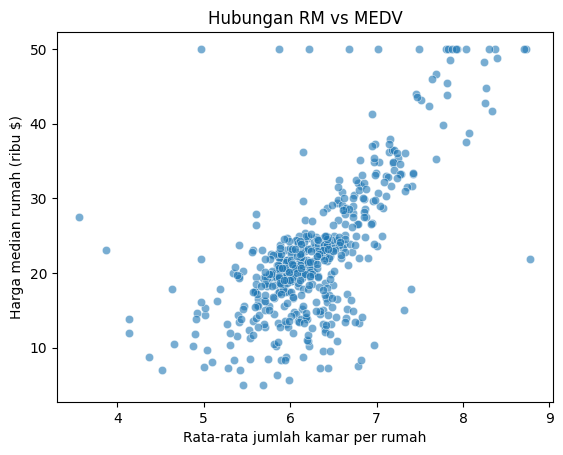

In [27]:
sns.scatterplot(data=df,
                x='RM',
                y='MEDV',
                alpha=0.6)
plt.title('Hubungan RM vs MEDV')
plt.xlabel('Rata-rata jumlah kamar per rumah')
plt.ylabel('Harga median rumah (ribu $)')
plt.show()

Interpretasi:
- Trend naik
- Makin banyak jumlah kamar , semakin mahal harga rumah
- Hubungan cukup linear
- Gunakan model `LinearRegression`

### c) Distribusi Target Y ( MEDV - Histogram )

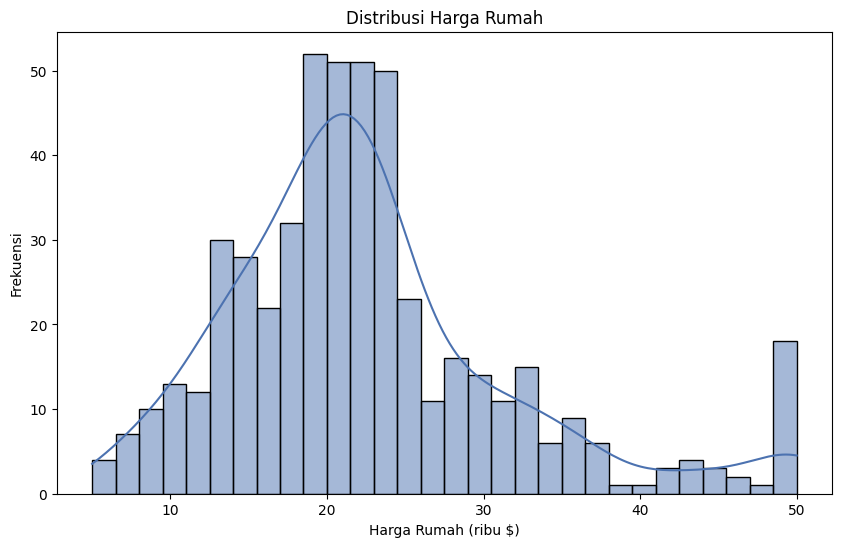

In [28]:
plt.figure(figsize=(10,6))
sns.histplot(df["MEDV"], bins=30, kde=True, color="#4C72B0")

plt.title("Distribusi Harga Rumah")
plt.xlabel("Harga Rumah (ribu $)")
plt.ylabel("Frekuensi")

plt.show()


Interpretasi:
- Sebagian besar rumah berharga 15–25 ribu $.
- Ada penumpukan di nilai 50 (kemungkinan harga 'dipotong' di batas atas) — hal yang baik untuk diketahui karena bisa memengaruhi error model.

## Splitting Dataset

- pisahkan **fitur (X)** dan **target (y)**, lalu bagi menjadi data latih (80%)
dan data uji (20%).
- Model dasar kita adalah **Regresi Linear**.

In [29]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [30]:
print("Bentuk X_train:", X_train.shape)
print("Bentuk X_test:", X_test.shape)
print("Bentuk y_train:", y_train.shape)
print("Bentuk y_test:", y_test.shape)

Bentuk X_train: (404, 13)
Bentuk X_test: (102, 13)
Bentuk y_train: (404,)
Bentuk y_test: (102,)


## Training Model

### a) Model Dasar LinearRegression

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Memahami dan Menghitung Metrik Evaluasi

Empat metrik utama untuk regresi:

| Metrik | Rumus singkat | Arti |
|--------|---------------|------|
| **MAE** | rata-rata \|y − ŷ\| | Rata-rata besar kesalahan (satuan sama dgn target). Mudah dibaca. |
| **MSE** | rata-rata (y − ŷ)² | Menghukum kesalahan besar lebih berat (satuan kuadrat). |
| **RMSE** | √MSE | Akar dari MSE → kembali ke satuan target. Paling sering dilaporkan. |
| **R²** | 1 − (error model / error rata-rata) | Proporsi variasi yang dijelaskan model (0–1; makin tinggi makin baik). |

In [32]:
LR_MAE = mean_absolute_error(y_test, y_pred)
LR_MSE = mean_squared_error(y_test, y_pred)
LR_RMSE = np.sqrt(LR_MSE)
LR_R2 = r2_score(y_test, y_pred)

print(f'MAE: {LR_MAE:.3f}')
print(f'MSE: {LR_MSE:.3f}')
print(f'RMSE: {LR_RMSE:.3f}')
print(f'R2: {LR_R2:.3f}')

MAE: 3.189
MSE: 24.291
RMSE: 4.929
R2: 0.669


Interpretasi:
- $R^2$ Score (0.669 atau ~66.9%):
  - Model Linear Regression mampu menjelaskan sekitar 66.9% variasi dari harga rumah aktual pada data uji.
  - Menunjukkan bahwa model linier memiliki batas kemampuan tertentu dalam menangkap pola data perumahan ini.
- MAE / Mean Absolute Error (3.189):
  - Secara rata-rata, prediksi harga rumah dari model ini meleset sekitar $3,189 dari harga aslinya.
- MSE (24.291) & RMSE (4.929):
  - Nilai RMSE sebesar 4.929 menunjukkan bahwa ada beberapa prediksi yang meleset cukup jauh.
  - Karena nilai RMSE lebih tinggi daripada MAE (4.929 vs 3.189), ini mengonfirmasi bahwa model sesekali melakukan kesalahan (error) yang cukup besar pada data tertentu, terutama pada rumah-rumah dengan karakteristik atau harga yang ekstrem (outlier).

### a) Visualisasi : Prediksi vs Aktual

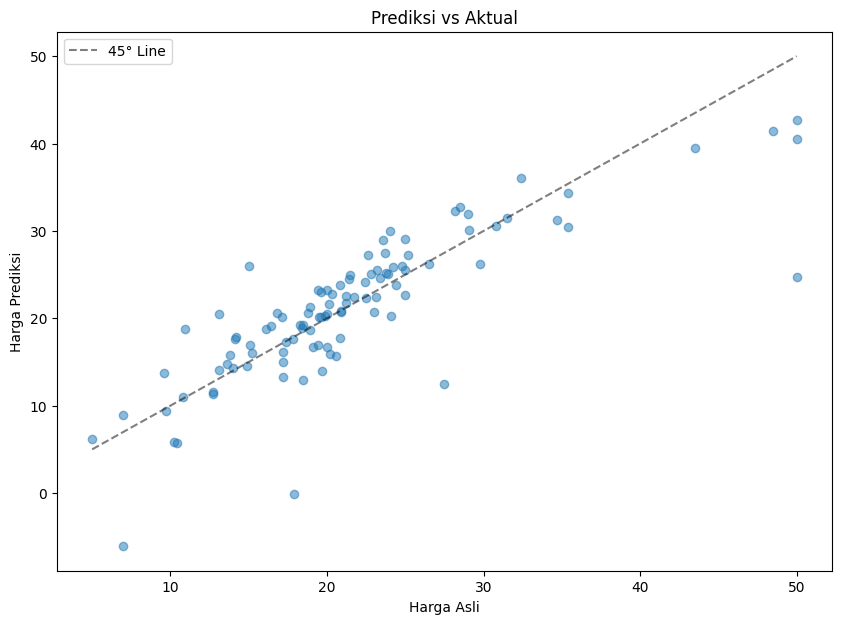

In [33]:
plt.figure(figsize=(10,7))

plt.scatter(y_test, y_pred, alpha=0.5)

lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'k--', alpha=0.5, label='45° Line')

plt.xlabel('Harga Asli')
plt.ylabel('Harga Prediksi')
plt.title('Prediksi vs Aktual')
plt.legend()

plt.show()

Interpretasi:
- Titik atau dots mengelompok disekitar garis putus.
- Penyimpangan terlihat jelas diharga tinggi ( sekitar 50 )tempat model terlihat unpredict




### b) Apakah hasil R-Score 0.67 itu Bagus? bandingkan dengan Baseline

In [34]:
from sklearn.dummy import DummyRegressor

In [39]:
from sklearn import metrics
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

#buat table perbandingan
metrics_summary = {
    'Model': ['Linear Regression', 'Baseline'],
    'R2 Score': [LR_R2, metrics.r2_score(y_test, y_pred_dummy)],
    'MAE': [LR_MAE, metrics.mean_absolute_error(y_test, y_pred_dummy)],
    'MSE': [LR_MSE, metrics.mean_squared_error(y_test, y_pred_dummy)],
    'RMSE': [LR_RMSE, np.sqrt(metrics.mean_squared_error(y_test, y_pred_dummy))]
}

metrics_df = pd.DataFrame(metrics_summary).round(3)
metrics_df.set_index('Model', inplace=True)
metrics_df


,R2 Score,MAE,MSE,RMSE
Model,,,,
Linear Regression,0.669,3.189,24.291,4.929
Baseline,-0.023,6.256,75.045,8.663


Interpretasi:

- $R^2$ Score:Linear Regression (0.669):
  - Model regresi linier mampu menjelaskan sekitar 66.9% variasi dari harga rumah aktual pada data uji
  - Baseline (-0.023): Model baseline (yang biasanya memprediksi nilai rata-rata target secara konstan tanpa melihat fitur) memiliki nilai $R^2$ negatif. Nilai negatif ini menunjukkan bahwa model baseline bekerja jauh lebih buruk daripada sekadar menebak nilai rata-rata, mengonfirmasi bahwa model regresi linier jauh lebih unggul dan bermakna dibandingkan tebakan acak/rata-rata dasar.

- MAE / Mean Absolute Error:
  - Linear Regression (3.189): Secara rata-rata, prediksi harga rumah dari model regresi linier meleset sekitar $3,189 dari harga aslinya.
  - Baseline (6.256): Model baseline memiliki rata-rata kesalahan absolut yang jauh lebih besar, yaitu sekitar $6,256, yang hampir dua kali lipat lebih buruk daripada regresi linier.

- MSE (Mean Squared Error) & RMSE (Root Mean Squared Error):
  - Linear Regression (MSE: 24.291, RMSE: 4.929): Angka RMSE sebesar 4.929 menunjukkan adanya beberapa prediksi yang meleset cukup jauh (terutama pada rumah dengan karakteristik ekstrem atau outlier), namun masih berada dalam batas wajar untuk sebuah model dasar.
  - Baseline (MSE: 75.045, RMSE: 8.663): Nilai error kuadrat dan akar error pada baseline melonjak sangat tinggi (RMSE mencapai 8.663), yang membuktikan bahwa model baseline sering membuat kesalahan prediksi yang sangat besar.

Kesimpulan:
  - Model Linear Regression menunjukkan performa yang jauh lebih superior dan valid secara statistik dibandingkan model Baseline, membuktikan bahwa fitur-fitur yang digunakan dalam regresi linier memberikan informasi yang sangat berguna untuk memprediksi harga rumah.

## Cross Validation

Masalah dengan satu kali split:
- skor bisa **beruntung atau apes** tergantung baris mana yang kebetulan masuk data uji.
- **K-Fold Cross-Validation** menyelesaikan ini dengan membagi data jadi *k* bagian (fold), lalu melatih & menguji model *k* kali — setiap fold bergantian menjadi data uji.
- Hasilnya **rata-rata skor** yang jauh lebih stabil dan dapat dipercaya.
- Kita pakai `cv=5` (5 fold).

Scikit-Learn memakai konvensi - makin tinggi makin baik -, sehingga nilai error dibuat negatif

In [40]:
k_fold = KFold(n_splits=5, shuffle=True, random_state=42)

In [41]:
# Kita ubah kembali ke nilai positif.
neg_mse = cross_val_score(LinearRegression(),
                          X,
                          y,
                          scoring='neg_mean_squared_error',
                          cv=k_fold)

rmse_cv = (-neg_mse) ** 0.5
r2_cv = cross_val_score(LinearRegression(),
                        X,
                        y,
                        scoring='r2',
                        cv=k_fold)

In [52]:
print(f'RMSE tiap Fold:', np.round(rmse_cv, 3))
print(f'R2 tiap Fold:', np.round(r2_cv, 3))

print(f'RMSE rata rata: {rmse_cv.mean():.3f} , (STD: {rmse_cv.std():.3f})')
print(f' R2  rata rata: {r2_cv.mean():.3f} , (STD: {r2_cv.std():.3f})')



RMSE tiap Fold: [4.929 4.568 5.138 4.837 4.742]
R2 tiap Fold: [0.669 0.734 0.71  0.776 0.687]
RMSE rata rata: 4.843 , (STD: 0.190)
 R2  rata rata: 0.715 , (STD: 0.037)


Interpretasi:
- Konsistensi Performa (Stabil):
  - Nilai standar deviasi (STD) untuk RMSE sangat kecil yaitu 0.190, dan $R^2$ juga kecil yaitu 0.037.
  - Ini menunjukkan bahwa performa model stabil dan konsisten di berbagai bagian data yang berbeda, dan tidak hanya bagus di satu bagian data saja (tidak overfit pada satu split tertentu).

- Rata-rata Akurasi ($R^2 = 0.715$ atau ~71.5%):
  - Secara keseluruhan, jika diuji ke berbagai subset data, model mampu menjelaskan sekitar 71.5% variasi dari harga rumah.
  - Angka ini memberikan gambaran yang lebih objektif dan dapat diandalkan dibandingkan hanya mengandalkan satu kali train/test split.

- Rata-rata Kesalahan (RMSE = 4.843):
  - Secara rata-rata, tingkat kesalahan prediksi model berada di kisaran angka tersebut di setiap lipatan data (fold), yang menunjukkan tingkat akurasi model yang merata di seluruh bagian dataset.

### a) Visualisasi Distribusi skor Cross Validation

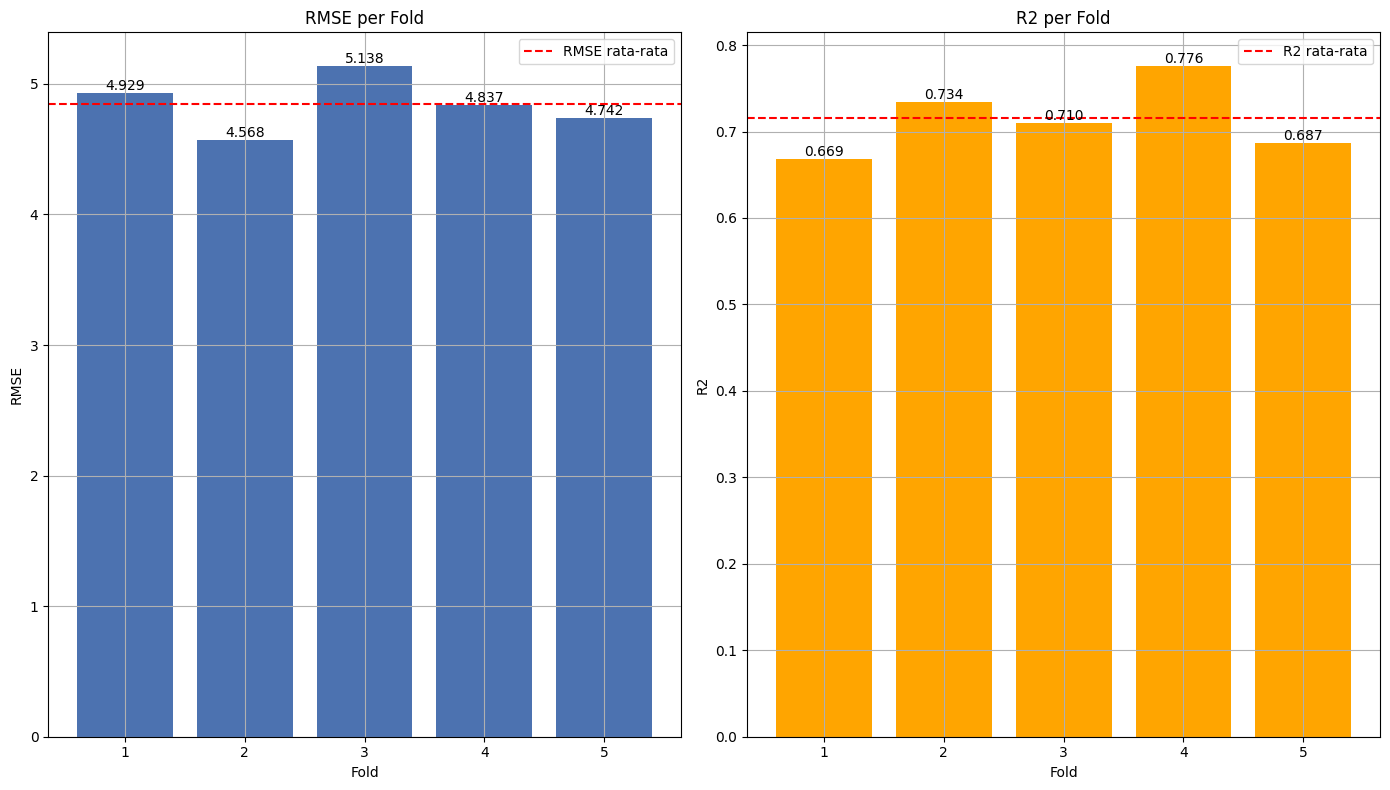

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14,8))

axes[0].bar(range(1, 6), rmse_cv, color='#4C72B0')
axes[0].set_xlabel('Fold')
axes[0].axhline(y=rmse_cv.mean(), color='r', linestyle='--')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE per Fold')
axes[0].legend(['RMSE rata-rata'])
for i, value in enumerate(rmse_cv):
  axes[0].text(i + 1, value, f'{value:.3f}', ha='center', va='bottom')

axes[1].bar(range(1, 6), r2_cv, color='orange')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R2')
axes[1].set_title('R2 per Fold')
axes[1].axhline(y=r2_cv.mean(), color='r', linestyle='--')
axes[1].legend(['R2 rata-rata'])
for i, value in enumerate(r2_cv):
  axes[1].text(i + 1, value, f'{value:.3f}', ha='center', va='bottom')

for ax in axes:
  ax.grid(True)

plt.tight_layout()
plt.show()

Interpretasi:
  - Konsisten & Stabil:
    - Tinggi batang pada grafik RMSE (kiri) dan $R^2$ (kanan) tidak jauh berbeda dari satu fold ke fold lainnya.
    - Garis putus-putus merah menunjukkan nilai rata-rata yang berada sangat dekat dengan setiap kolom.  

  - Artinya:
    - Model bekerja secara konsisten di berbagai bagian data yang berbeda, yang membuktikan bahwa performa model stabil dan tidak bergantung pada satu bagian data pelatihan tertentu saja.

## Overfitting Check and Detection

**Overfitting** terjadi saat model sangat bagus di data latih tetapi buruk di data baru.
- Cara cepat mendeteksinya:
  - bandingkan skor pada **data latih** vs **data uji**.
  - Jika R² latih jauh lebih tinggi dari R² uji, model kemungkinan menghafal, bukan belajar pola.

In [69]:
r2_tr = r2_score(y_train, model.predict(X_train))
r2_te = r2_score(y_test, y_pred)

print(f'R2 train: {r2_tr:.3f}')
print(f'R2 test: {r2_te:.3f}')
print(f'Selisih R2: {abs(r2_tr - r2_te):.3f}')

R2 train: 0.751
R2 test: 0.669
Selisih R2: 0.082


Interpretasi:
- Tidak Terjadi Overfitting yang Parah (Aman):
  - Meskipun skor data latih (0.751) sedikit lebih tinggi daripada data uji (0.669), selisihnya sangat kecil, yaitu hanya 0.082 (sekitar 8.2%).

- Artinya:
  - Model kita bekerja dengan baik dan konsisten.
  - Perbedaan kecil ini adalah hal yang wajar dalam machine learning.
  
Ini membuktikan bahwa model benar-benar belajar pola umum dari data, bukan sekadar "menghafal" jawaban dari data latihan.

## Kesimpulan dan Insight
1. Pemahaman Metrik Evaluasi Regresi (MAE, MSE, RMSE, R²):

    - MAE (Mean Absolute Error): Memberikan gambaran rata-rata kesalahan absolut secara langsung dalam satuan asli target.

   - MSE (Mean Squared Error) & RMSE (Root Mean Squared Error): Memberikan penalti yang lebih besar pada error yang bernilai tinggi karena adanya proses kuadrat, sehingga RMSE sangat berguna untuk mendeteksi adanya outlier atau prediksi meleset yang signifikan.

   - R² (R-Squared): Menunjukkan seberapa besar variasi dari data target yang mampu dijelaskan oleh model fitur-fitur independen. Nilai mendekati 1 menunjukkan performa yang sangat baik.

2. Pentingnya Skala Target:

    - Saat menafsirkan nilai RMSE, penting untuk selalu melihat rentang nilai dari variabel target (misalnya harga rumah dalam ribuan dolar). Nilai RMSE harus dibandingkan dengan rentang dan rata-rata data target agar bisa dinilai apakah error tersebut masih dalam batas wajar.

3. Cross-Validation untuk Stabilitas Model (cross_val_score):

    - Pembagian data hanya sekali lewat train_test_split terkadang menghasilkan skor yang terlalu optimis atau pesimis tergantung bagian data mana yang masuk ke data uji.

    - Dengan menggunakan Cross-Validation (cv=5), model diuji secara bergantian pada beberapa bagian data (folds), sehingga menghasilkan metrik evaluasi yang jauh lebih stabil, objektif, dan terhindar dari bias pembagian data.

4. Karakteristik Dataset Boston Housing:

    - Dataset ini memiliki fitur-fitur numerik yang lengkap dan bersih tanpa adanya missing value, menjadikannya studi kasus yang ideal untuk mempelajari dasar-dasar evaluasi model regresi linear secara mendalam.